# Eksperimen MSML — Prediksi Sepsis pada Pasien ICU
**Nama:** Naimatul Ulumiyah 
**Dataset:** Prediction of Sepsis (PhysioNet / Kaggle — salikhussaini49)  
**Task:** Binary Classification — Sepsis Early Warning (SepsisLabel)


---
# **1. Perkenalan Dataset**

## 1.1 Latar Belakang Klinis

**Sepsis** adalah respons imun tubuh yang mengancam jiwa terhadap infeksi, yang dapat berkembang menjadi syok septik dan kegagalan multi-organ. Menurut **WHO (2020)**, sepsis menyebabkan sekitar **11 juta kematian per tahun** — hampir 1 dari 5 kematian di seluruh dunia. Di ICU (Intensive Care Unit), mortalitas pasien sepsis mencapai **30–50%**, dan setiap jam keterlambatan pemberian antibiotik meningkatkan risiko kematian sebesar **7%**.

Deteksi dini sepsis menjadi **kritis** karena:
1. Gejala awal (subtle vital sign changes) sering diabaikan atau tersembunyi di balik noise data klinis
2. Perkembangan dari infeksi → sepsis → syok septik bisa terjadi dalam **6–12 jam**
3. Tanda-tanda klinis seperti HR, Temp, RR, dan WBC sudah bisa berubah **sebelum diagnosis formal** ditegakkan

## 1.2 Deskripsi Dataset

Dataset ini bersumber dari **PhysioNet Computing in Cardiology Challenge 2019** dan tersedia publik di Kaggle. Dataset terdiri dari **40.000+ file .psv** (pipe-separated values), di mana setiap file merepresentasikan **satu pasien ICU** dengan data time-series per jam.

| Kelompok Fitur | Jumlah Fitur | Contoh |
|---|---|---|
| **Vital Signs** | 8 | HR, O2Sat, Temp, SBP, MAP, DBP, Resp, EtCO2 |
| **Lab Values** | 26 | BaseExcess, HCO3, pH, WBC, Lactate, Creatinine, dll. |
| **Demographics** | 6 | Age, Gender, Unit1, Unit2, HospAdmTime, ICULOS |
| **Target** | 1 | SepsisLabel (0 = non-sepsis, 1 = sepsis dalam 6 jam) |

**Label Logic:**  
- `SepsisLabel = 1` → jika waktu saat ini `t ≥ t_sepsis − 6` (prediksi 6 jam sebelum diagnosis)
- `SepsisLabel = 0` → sebelum window tersebut atau pasien non-sepsis

**Tantangan utama dataset ini:**
- **Missing values ekstrem** → banyak lab value hanya diukur saat klinis memerlukan (bukan rutin)
- **Class imbalance berat** → hanya ~8% pasien mengembangkan sepsis
- **Time-series nature** → setiap baris bukan independen — tren temporal sangat bermakna klinis


---
# **2. Import Library**


In [4]:
import os
import glob
import warnings
import json
warnings.filterwarnings('ignore')

#Data Manipulation
import numpy as np
import pandas as pd
from scipy import stats
from scipy.stats import linregress

#Visualisasi
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

#Preprocessing
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import VarianceThreshold
from imblearn.over_sampling import SMOTE

#Model & Evaluation
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, precision_recall_curve, average_precision_score
)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'font.family': 'DejaVu Sans'})
COLORS = {'sepsis': "#A81313", 'non_sepsis': '#4A90D9', 'neutral': '#6C757D'}




---
# **3. Memuat Dataset**

Dataset terdiri dari 40.000+ file .psv individual (satu file per pasien). Kita perlu:
1. Mendeteksi lokasi file secara otomatis
2. Membaca dan menggabungkan seluruh file menjadi satu DataFrame
3. Menambahkan kolom patient_id untuk keperluan analisis time-series


In [5]:
DATA_DIR = 'sepsis_preprocessing/training_setA/training/'

all_files = glob.glob(os.path.join(DATA_DIR, '*.psv'))
print(f'Ditemukan {len(all_files):,} file .psv')

Ditemukan 20,336 file .psv


In [6]:
# MERGE SEMUA FILE .PSV
def load_all_psv(file_list, max_files=None):
    if max_files:
        file_list = file_list[:max_files]
    
    dfs = []
    for i, fp in enumerate(file_list):
        try:
            df = pd.read_csv(fp, sep='|')
            pid = os.path.splitext(os.path.basename(fp))[0] 
            df.insert(0, 'patient_id', pid)
            df.insert(1, 'time_step', range(len(df)))
            dfs.append(df)
        except Exception as e:
            print(f'gabisa {fp}: {e}')
        
        if (i + 1) % 5000 == 0:
            print(f'   ... {i+1:,} / {len(file_list):,} file diproses')
    
    combined = pd.concat(dfs, ignore_index=True)
    print(f'\n Merge done say: {combined.shape[0]:,} baris × {combined.shape[1]} kolom')
    return combined


df_raw = load_all_psv(all_files) 

print(f'\n DF:')
print(f'Shape: {df_raw.shape}')
print(f'Unique Patients: {df_raw["patient_id"].nunique():,}')
print(f'Kolom: {list(df_raw.columns)}')


   ... 5,000 / 20,336 file diproses
   ... 10,000 / 20,336 file diproses
   ... 15,000 / 20,336 file diproses
   ... 20,000 / 20,336 file diproses

 Merge done say: 790,215 baris × 43 kolom

 DF:
Shape: (790215, 43)
Unique Patients: 20,336
Kolom: ['patient_id', 'time_step', 'HR', 'O2Sat', 'Temp', 'SBP', 'MAP', 'DBP', 'Resp', 'EtCO2', 'BaseExcess', 'HCO3', 'FiO2', 'pH', 'PaCO2', 'SaO2', 'AST', 'BUN', 'Alkalinephos', 'Calcium', 'Chloride', 'Creatinine', 'Bilirubin_direct', 'Glucose', 'Lactate', 'Magnesium', 'Phosphate', 'Potassium', 'Bilirubin_total', 'TroponinI', 'Hct', 'Hgb', 'PTT', 'WBC', 'Fibrinogen', 'Platelets', 'Age', 'Gender', 'Unit1', 'Unit2', 'HospAdmTime', 'ICULOS', 'SepsisLabel']


In [7]:
display(df_raw.head(10))
print('\n datatypes')
print(df_raw.dtypes)
print('\n numerik')
display(df_raw.describe().T.round(3))


,patient_id,time_step,HR,O2Sat,Temp,SBP,MAP,DBP,Resp,EtCO2,...,WBC,Fibrinogen,Platelets,Age,Gender,Unit1,Unit2,HospAdmTime,ICULOS,SepsisLabel
0,p014977,0,80.0,100.0,36.50,121.00,58.0,41.00,13.5,NaN,...,9.9,223.0,160.0,77.27,1,0.0,1.0,-69.14,3,0
1,p014977,1,76.0,100.0,36.25,113.25,61.0,41.50,12.0,NaN,...,9.9,NaN,NaN,77.27,1,0.0,1.0,-69.14,4,0
2,p014977,2,80.0,100.0,36.25,132.75,71.5,46.25,12.0,NaN,...,NaN,NaN,NaN,77.27,1,0.0,1.0,-69.14,5,0
3,p014977,3,78.0,100.0,36.10,103.50,58.0,43.00,12.0,NaN,...,NaN,NaN,NaN,77.27,1,0.0,1.0,-69.14,6,0
4,p014977,4,74.0,100.0,36.00,128.75,69.5,44.50,12.5,NaN,...,NaN,NaN,NaN,77.27,1,0.0,1.0,-69.14,7,0
5,p014977,5,76.0,100.0,36.20,124.00,65.0,41.50,14.0,NaN,...,12.0,NaN,169.0,77.27,1,0.0,1.0,-69.14,8,0
6,p014977,6,70.0,100.0,36.10,120.25,65.0,43.00,14.0,NaN,...,12.0,NaN,NaN,77.27,1,0.0,1.0,-69.14,9,0
7,p014977,7,67.0,100.0,36.40,130.50,73.0,49.00,14.0,NaN,...,NaN,NaN,NaN,77.27,1,0.0,1.0,-69.14,10,0
8,p014977,8,64.5,100.0,36.55,116.75,62.5,42.50,14.0,NaN,...,NaN,NaN,NaN,77.27,1,0.0,1.0,-69.14,11,0
9,p014977,9,65.0,99.0,36.90,117.50,61.0,43.50,21.0,NaN,...,10.1,NaN,154.0,77.27,1,0.0,1.0,-69.14,12,0



 datatypes
patient_id           object
time_step             int64
HR                  float64
O2Sat               float64
Temp                float64
SBP                 float64
MAP                 float64
DBP                 float64
Resp                float64
EtCO2               float64
BaseExcess          float64
HCO3                float64
FiO2                float64
pH                  float64
PaCO2               float64
SaO2                float64
AST                 float64
BUN                 float64
Alkalinephos        float64
Calcium             float64
Chloride            float64
Creatinine          float64
Bilirubin_direct    float64
Glucose             float64
Lactate             float64
Magnesium           float64
Phosphate           float64
Potassium           float64
Bilirubin_total     float64
TroponinI           float64
Hct                 float64
Hgb                 float64
PTT                 float64
WBC                 float64
Fibrinogen          float64
Platelet

,count,mean,std,min,25%,50%,75%,max
time_step,790215.0,25.332,27.954,0.00,9.00,20.00,33.00,335.00
HR,729026.0,84.985,16.940,20.00,73.00,84.00,96.00,280.00
O2Sat,695136.0,97.266,2.909,20.00,96.00,98.00,99.50,100.00
Temp,266901.0,37.027,0.780,20.90,36.56,37.06,37.55,42.22
SBP,670014.0,120.962,21.521,22.00,105.00,118.50,134.00,281.00
MAP,709357.0,78.767,15.044,20.00,68.00,77.00,87.33,300.00
DBP,409918.0,59.986,12.573,20.00,51.00,58.50,67.00,298.00
Resp,712957.0,18.773,5.396,1.00,15.00,18.00,22.00,69.00
EtCO2,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BaseExcess,82381.0,-0.648,4.287,-32.00,-3.00,0.00,1.00,100.00


---
# **4. Exploratory Data Analysis (EDA)**

EDA ini terdiri dari **7 seksi** yang masing-masing menjawab pertanyaan klinis berbeda:

| Seksi | Pertanyaan |
|---|---|
| 4.1 | Seberapa parah class imbalance? |
| 4.2 | Fitur mana yang paling banyak missing? |
| 4.3 | Apakah distribusi temporal berbeda antar kelas? |
| 4.4 | Bagaimana distribusi vital signs per kelas? |
| 4.5 | Apakah lab values menunjukkan separasi klinis? |
| 4.6 | Bagaimana profil demografis pasien? |
| 4.7 | Fitur mana yang paling berkorelasi dengan sepsis? |


## 4.1 Class Imbalance Analysis

> **Hipotesis klinis:** Hanya sebagian kecil pasien ICU yang berkembang menjadi sepsis, sehingga distribusi label sangat tidak seimbang.


Distribusi Label (Row-Level)
              Count  Pct (%)
SepsisLabel                 
0            773079    97.83
1             17136     2.17

Distribusi Pasien (Patient-Level)
             Patients  Pct (%)
ever_sepsis                   
0               18546     91.2
1                1790      8.8


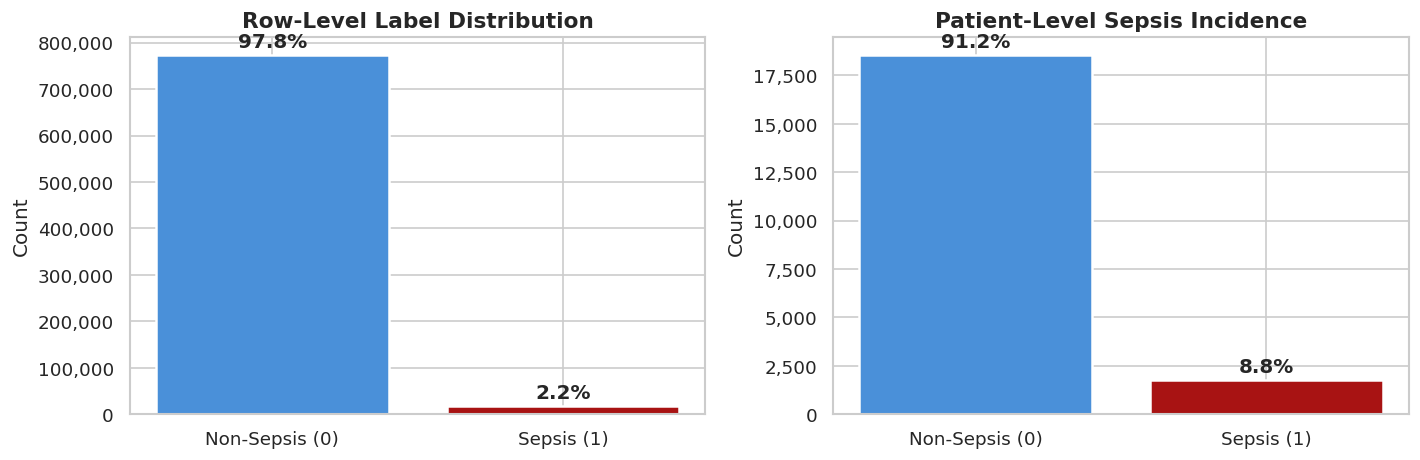


 Imbalance Ratio (0:1) = 45.1:1
Insight: Class imbalance signifikan → wajib menggunakan SMOTE + stratified split


In [8]:
label_counts = df_raw['SepsisLabel'].value_counts()
label_pct    = df_raw['SepsisLabel'].value_counts(normalize=True) * 100

print('Distribusi Label (Row-Level)')
print(pd.DataFrame({'Count': label_counts, 'Pct (%)': label_pct.round(2)}))

# berapa pasien yang PERNAH sepsis?
patient_sepsis = df_raw.groupby('patient_id')['SepsisLabel'].max().reset_index()
patient_sepsis.columns = ['patient_id', 'ever_sepsis']
ps_counts = patient_sepsis['ever_sepsis'].value_counts()
ps_pct    = patient_sepsis['ever_sepsis'].value_counts(normalize=True) * 100

print('\nDistribusi Pasien (Patient-Level)')
print(pd.DataFrame({'Patients': ps_counts, 'Pct (%)': ps_pct.round(2)}))

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, counts, pcts, title in zip(
    axes,
    [label_counts, ps_counts],
    [label_pct, ps_pct],
    ['Row-Level Label Distribution', 'Patient-Level Sepsis Incidence']
):
    bars = ax.bar(
        ['Non-Sepsis (0)', 'Sepsis (1)'],
        counts.values,
        color=[COLORS['non_sepsis'], COLORS['sepsis']],
        edgecolor='white', linewidth=1.5
    )
    for bar, pct in zip(bars, pcts.values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + counts.max() * 0.01,
            f'{pct:.1f}%', ha='center', va='bottom', fontweight='bold'
        )
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_ylabel('Count')
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.savefig('eda_01_class_imbalance.png', dpi=150, bbox_inches='tight')
plt.show()

imbalance_ratio = label_counts[0] / label_counts[1]
print(f'\n Imbalance Ratio (0:1) = {imbalance_ratio:.1f}:1')
print('Insight: Class imbalance signifikan → wajib menggunakan SMOTE + stratified split')


## 4.2 Missing Value Analysis

> **Insight klinis:** Lab values memiliki missing >70% karena hanya diukur saat ada indikasi klinis. Ini bukan *random missing* — missingness sendiri menjadi sinyal klinis.


=== Top-20 Kolom dengan Missing Tertinggi ===


,missing_count,missing_pct
EtCO2,790215,100.00
TroponinI,789250,99.88
Bilirubin_direct,789033,99.85
Fibrinogen,784185,99.24
Bilirubin_total,780522,98.77
Alkalinephos,778683,98.54
AST,778395,98.50
Lactate,763072,96.57
PTT,751909,95.15
SaO2,751055,95.04


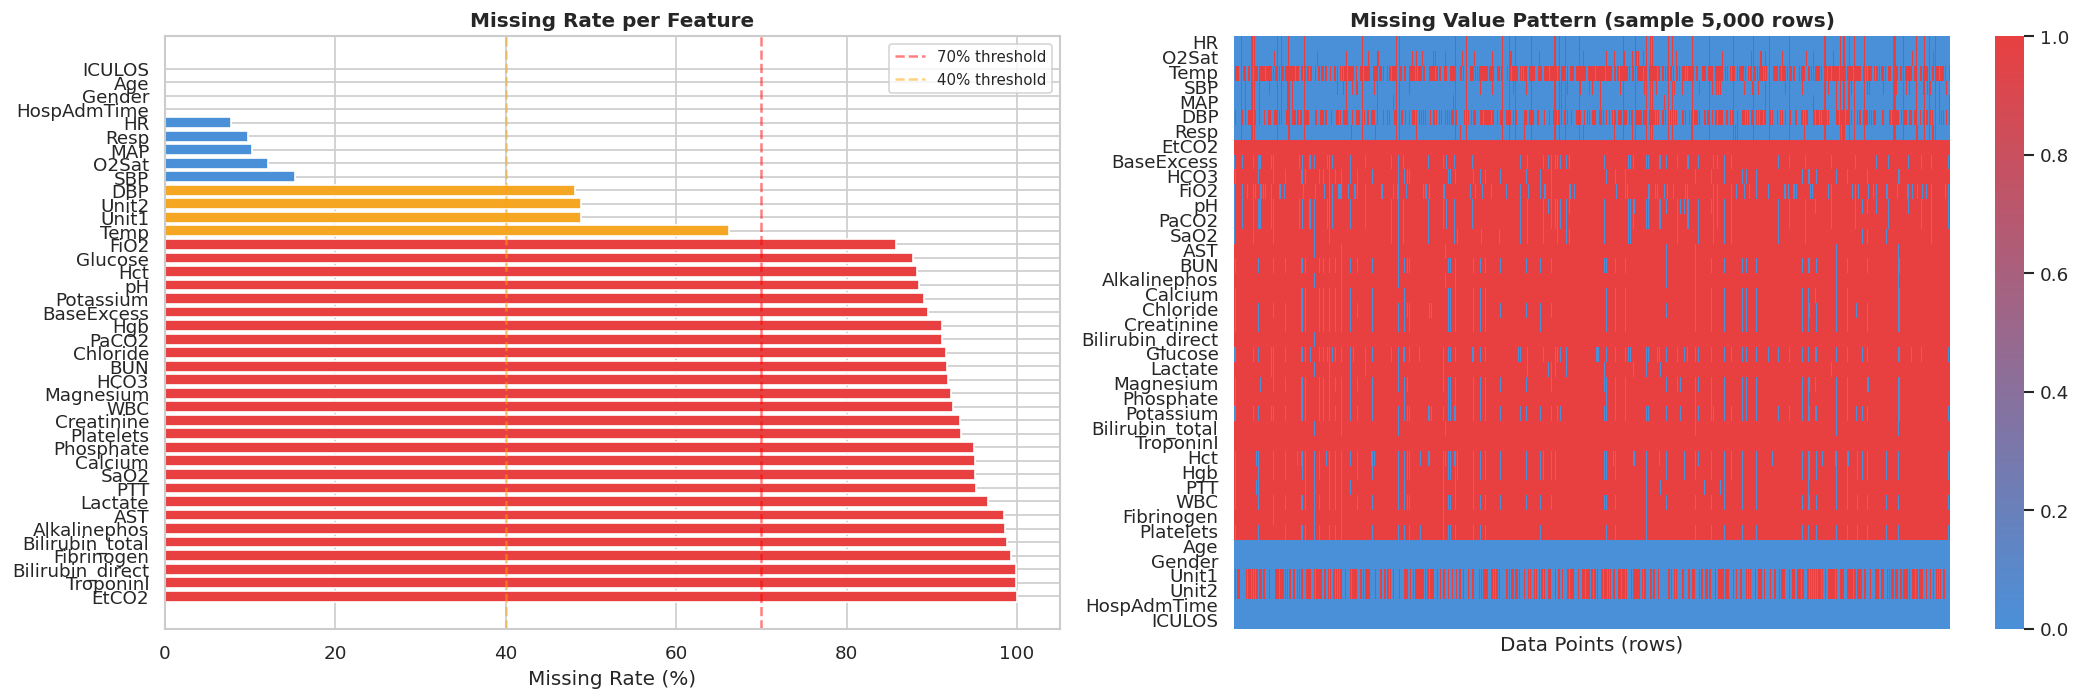


 27 fitur memiliki missing rate > 70% (mayoritas lab values)
 Missingness itu sendiri = informasi klinis (patient tidak diukur = mungkin stabil)


In [9]:
# Hitung missing rate per kolom
feature_cols = [c for c in df_raw.columns if c not in ['patient_id', 'time_step', 'SepsisLabel']]
missing_df = pd.DataFrame({
    'missing_count': df_raw[feature_cols].isnull().sum(),
    'missing_pct'  : df_raw[feature_cols].isnull().mean() * 100
}).sort_values('missing_pct', ascending=False)

print('=== Top-20 Kolom dengan Missing Tertinggi ===')
display(missing_df.head(20).round(2))

# Heatmap missing value 
sample_idx = df_raw.sample(min(5000, len(df_raw)), random_state=42).index
missing_matrix = df_raw.loc[sample_idx, feature_cols].isnull().astype(int)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Bar chart missing rate
ax = axes[0]
colors_bar = ['#E84040' if v > 70 else '#F5A623' if v > 40 else '#4A90D9'
              for v in missing_df['missing_pct']]
ax.barh(missing_df.index, missing_df['missing_pct'], color=colors_bar)
ax.axvline(70, color='red', linestyle='--', alpha=0.5, label='70% threshold')
ax.axvline(40, color='orange', linestyle='--', alpha=0.5, label='40% threshold')
ax.set_xlabel('Missing Rate (%)')
ax.set_title('Missing Rate per Feature', fontweight='bold')
ax.legend(fontsize=9)

# Heatmap
ax2 = axes[1]
cmap = LinearSegmentedColormap.from_list('mv', ['#4A90D9', '#E84040'])
sns.heatmap(
    missing_matrix.T, ax=ax2, cmap=cmap, cbar=True,
    xticklabels=False, yticklabels=True
)
ax2.set_title('Missing Value Pattern (sample 5,000 rows)', fontweight='bold')
ax2.set_xlabel('Data Points (rows)')

plt.tight_layout()
plt.savefig('eda_02_missing_values.png', dpi=150, bbox_inches='tight')
plt.show()

n_high_miss = (missing_df['missing_pct'] > 70).sum()
print(f'\n {n_high_miss} fitur memiliki missing rate > 70% (mayoritas lab values)')
print(' Missingness itu sendiri = informasi klinis (patient tidak diukur = mungkin stabil)')


## 4.3 Temporal Distribution (ICU Length of Stay)

> **Hipotesis:** Pasien sepsis cenderung memiliki ICULOS lebih panjang dan SepsisLabel mulai aktif pada jam-jam awal ICU.


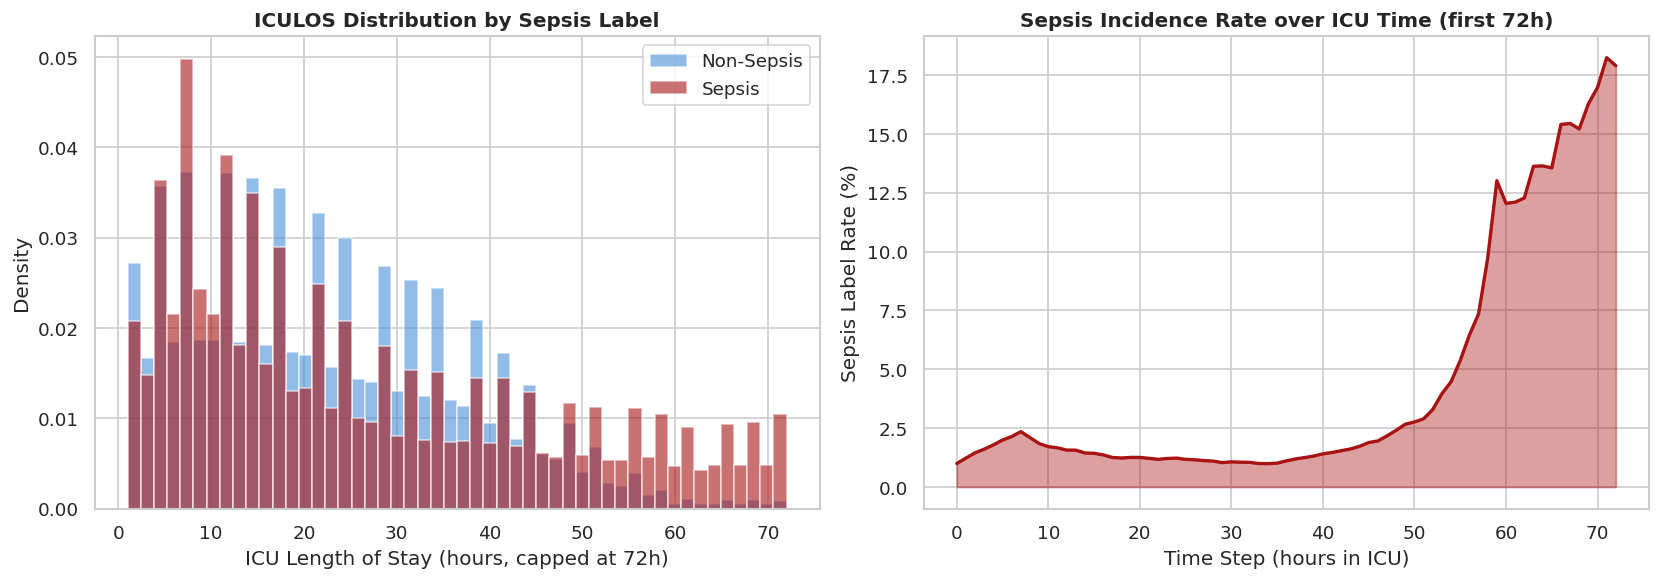

Sepsis incidence meningkat pada jam-jam pertama ICU  (early warning window sangat kritis)


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribusi ICULOS per kelas
ax = axes[0]
for label, color, name in [(0, COLORS['non_sepsis'], 'Non-Sepsis'), (1, COLORS['sepsis'], 'Sepsis')]:
    subset = df_raw[df_raw['SepsisLabel'] == label]['ICULOS'].dropna()
    subset_clipped = subset[subset <= 72]  
    ax.hist(subset_clipped, bins=50, alpha=0.6, color=color, label=name, density=True)
ax.set_xlabel('ICU Length of Stay (hours, capped at 72h)')
ax.set_ylabel('Density')
ax.set_title('ICULOS Distribution by Sepsis Label', fontweight='bold')
ax.legend()

# SepsisLabel across time steps
ax2 = axes[1]
# Frekuensi label=1 per time_step
hourly_sepsis = df_raw[df_raw['SepsisLabel'] == 1].groupby('time_step').size()
hourly_total  = df_raw.groupby('time_step').size()
hourly_rate   = (hourly_sepsis / hourly_total * 100).fillna(0)
hourly_rate   = hourly_rate[hourly_rate.index <= 72]

ax2.fill_between(hourly_rate.index, hourly_rate.values, alpha=0.4, color=COLORS['sepsis'])
ax2.plot(hourly_rate.index, hourly_rate.values, color=COLORS['sepsis'], linewidth=2)
ax2.set_xlabel('Time Step (hours in ICU)')
ax2.set_ylabel('Sepsis Label Rate (%)')
ax2.set_title('Sepsis Incidence Rate over ICU Time (first 72h)', fontweight='bold')

plt.tight_layout()
plt.savefig('eda_03_temporal.png', dpi=150, bbox_inches='tight')
plt.show()

print('Sepsis incidence meningkat pada jam-jam pertama ICU  (early warning window sangat kritis)')


## 4.4 Vital Signs: Violin Plot per Kelas

> **Hipotesis klinis:** Pasien sepsis menunjukkan abnormalitas vital signs sesuai kriteria SIRS: HR > 90, Temp < 36°C atau > 38°C, Resp > 20, SBP < 90.


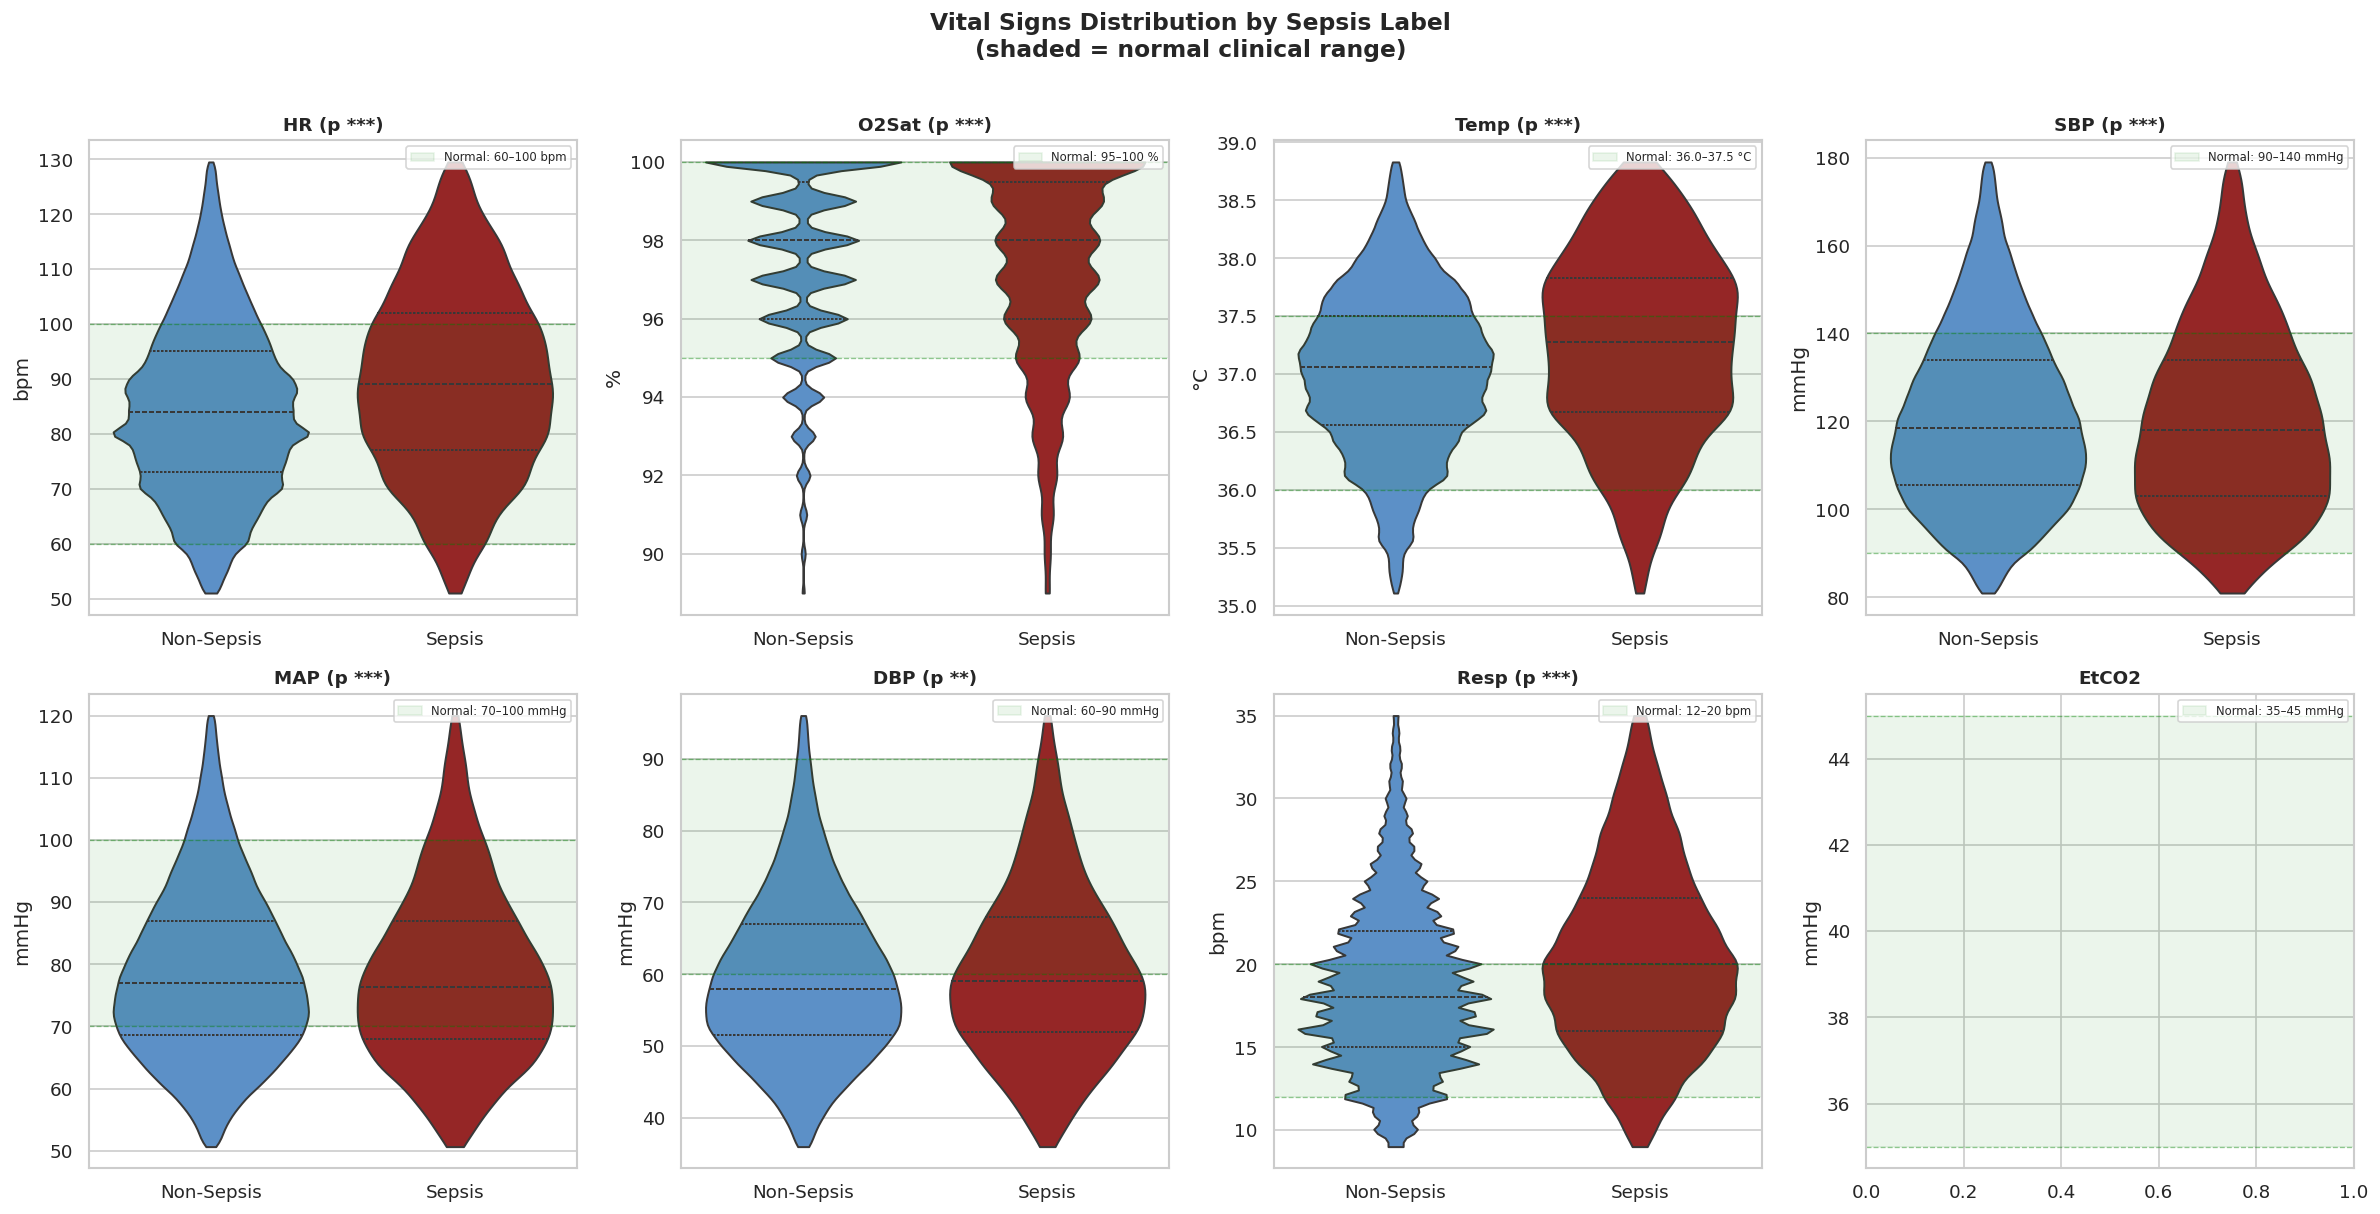

 HR, Resp, dan MAP menunjukkan perbedaan signifikan (*** p<0.001) antara kelas.
 Temp pada pasien sepsis menunjukkan bimodal yaitu hipotermia DAN hipertermia (sesuai Sepsis-3)


In [11]:
VITAL_SIGNS = ['HR', 'O2Sat', 'Temp', 'SBP', 'MAP', 'DBP', 'Resp', 'EtCO2']

# Referensi nilai normal klinis untuk anotasi
VITAL_NORMAL = {
    'HR'    : (60, 100, 'bpm'),
    'O2Sat' : (95, 100, '%'),
    'Temp'  : (36.0, 37.5, '°C'),
    'SBP'   : (90, 140, 'mmHg'),
    'MAP'   : (70, 100, 'mmHg'),
    'DBP'   : (60, 90, 'mmHg'),
    'Resp'  : (12, 20, 'bpm'),
    'EtCO2' : (35, 45, 'mmHg'),
}

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

plot_df = df_raw[VITAL_SIGNS + ['SepsisLabel']].dropna(subset=VITAL_SIGNS, how='all')
plot_df['Label'] = plot_df['SepsisLabel'].map({0: 'Non-Sepsis', 1: 'Sepsis'})

for i, feat in enumerate(VITAL_SIGNS):
    ax = axes[i]
    data_feat = plot_df[[feat, 'Label']].dropna()
    
    q1, q99 = data_feat[feat].quantile([0.01, 0.99])
    data_feat = data_feat[(data_feat[feat] >= q1) & (data_feat[feat] <= q99)]
    
    sns.violinplot(
        data=data_feat, x='Label', y=feat, ax=ax,
        palette={'Non-Sepsis': COLORS['non_sepsis'], 'Sepsis': COLORS['sepsis']},
        inner='quartile', cut=0, linewidth=1.2
    )
    
    # Garis normal range
    lo, hi, unit = VITAL_NORMAL[feat]
    ax.axhspan(lo, hi, alpha=0.08, color='green', label=f'Normal: {lo}–{hi} {unit}')
    ax.axhline(lo, color='green', linestyle='--', alpha=0.4, linewidth=0.8)
    ax.axhline(hi, color='green', linestyle='--', alpha=0.4, linewidth=0.8)
    
    # Mann-Whitney U test
    g0 = data_feat[data_feat['Label'] == 'Non-Sepsis'][feat].values
    g1 = data_feat[data_feat['Label'] == 'Sepsis'][feat].values
    if len(g0) > 0 and len(g1) > 0:
        _, pval = stats.mannwhitneyu(g0, g1, alternative='two-sided')
        sig = '***' if pval < 0.001 else '**' if pval < 0.01 else '*' if pval < 0.05 else 'ns'
        ax.set_title(f'{feat} (p {sig})', fontsize=11, fontweight='bold')
    else:
        ax.set_title(feat, fontsize=11, fontweight='bold')
    
    ax.set_xlabel('')
    ax.set_ylabel(VITAL_NORMAL[feat][2])
    ax.legend(fontsize=7, loc='upper right')

plt.suptitle('Vital Signs Distribution by Sepsis Label\n(shaded = normal clinical range)', 
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('eda_04_vitalsigns_violin.png', dpi=150, bbox_inches='tight')
plt.show()

print(' HR, Resp, dan MAP menunjukkan perbedaan signifikan (*** p<0.001) antara kelas.')
print(' Temp pada pasien sepsis menunjukkan bimodal yaitu hipotermia DAN hipertermia (sesuai Sepsis-3)')


## 4.5 Lab Values: Boxplot Key Markers

> **Hipotesis klinis:** Laktat, WBC, Kreatinin, dan Bilirubin adalah biomarker sepsis yang digunakan dalam SOFA score. Kita harapkan ada perbedaan bermakna antar kelas.


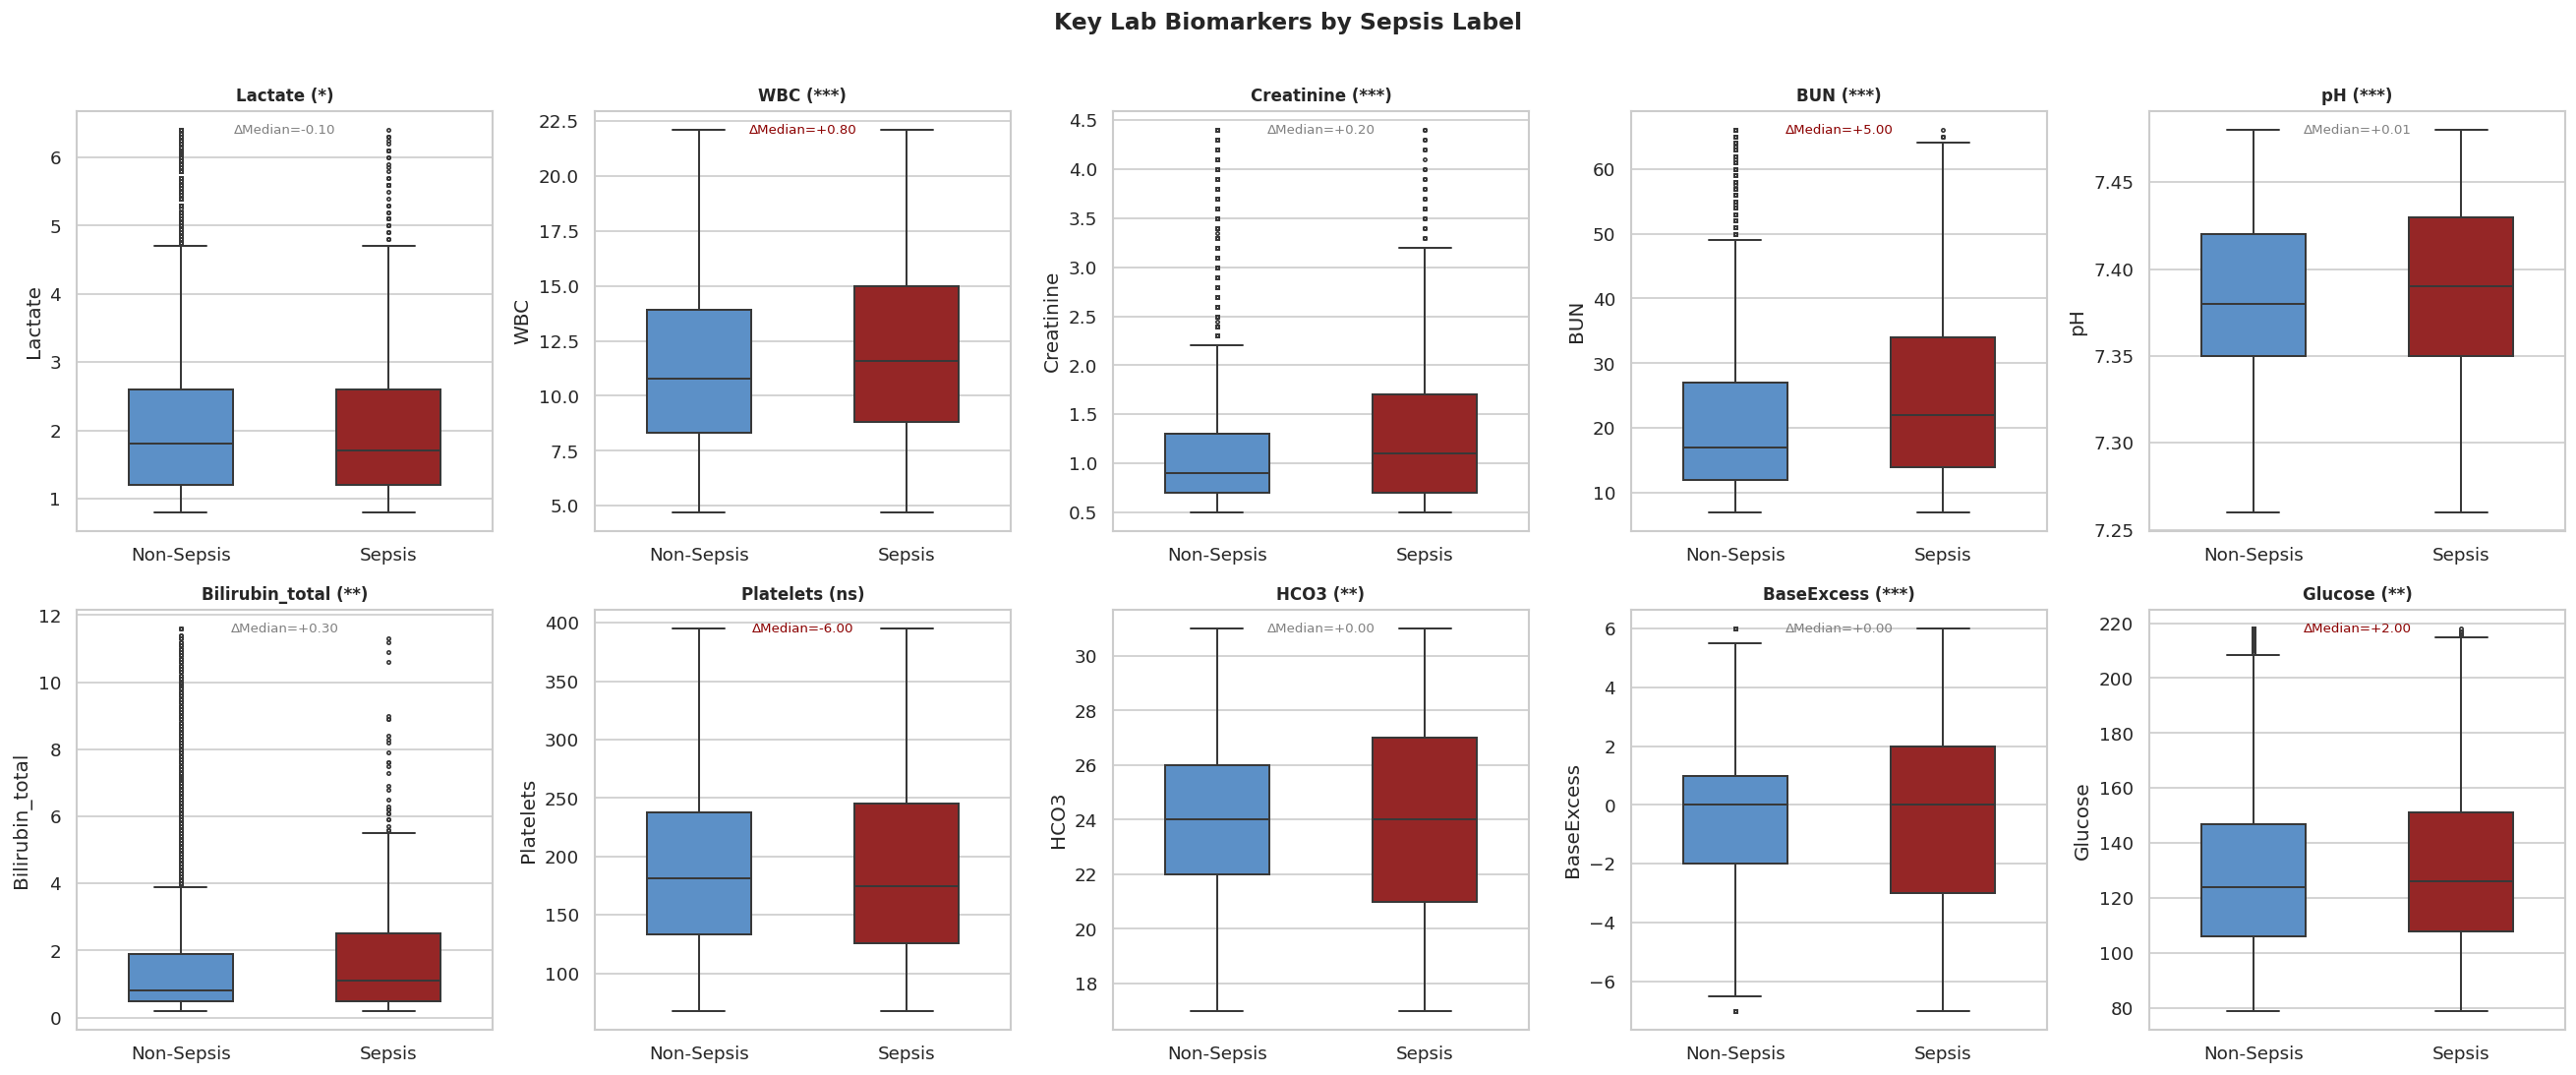

Lactate tinggi (organ hypoperfusion), WBC tinggi (infection), Creatinine tinggi (renal dysfunction)
pH rendah dan HCO3 rendah pada sepsis menjadi metabolic acidosis
Platelets rendah pada sepsis  DIC (disseminated intravascular coagulation)


In [12]:
KEY_LABS = ['Lactate', 'WBC', 'Creatinine', 'BUN', 'pH', 'Bilirubin_total',
            'Platelets', 'HCO3', 'BaseExcess', 'Glucose']

fig, axes = plt.subplots(2, 5, figsize=(22, 9))
axes = axes.flatten()

plot_lab = df_raw[KEY_LABS + ['SepsisLabel']].copy()
plot_lab['Label'] = plot_lab['SepsisLabel'].map({0: 'Non-Sepsis', 1: 'Sepsis'})

for i, feat in enumerate(KEY_LABS):
    ax = axes[i]
    data_feat = plot_lab[[feat, 'Label']].dropna()
    
    if len(data_feat) < 10:
        ax.set_visible(False)
        continue
    
    q05, q95 = data_feat[feat].quantile([0.05, 0.95])
    data_feat = data_feat[(data_feat[feat] >= q05) & (data_feat[feat] <= q95)]
    
    sns.boxplot(
        data=data_feat, x='Label', y=feat, ax=ax,
        palette={'Non-Sepsis': COLORS['non_sepsis'], 'Sepsis': COLORS['sepsis']},
        linewidth=1.2, fliersize=2, width=0.5
    )
    
    g0 = data_feat[data_feat['Label'] == 'Non-Sepsis'][feat].values
    g1 = data_feat[data_feat['Label'] == 'Sepsis'][feat].values
    if len(g0) > 5 and len(g1) > 5:
        _, pval = stats.mannwhitneyu(g0, g1, alternative='two-sided')
        sig = '***' if pval < 0.001 else '**' if pval < 0.01 else '*' if pval < 0.05 else 'ns'
        ax.set_title(f'{feat} ({sig})', fontsize=10, fontweight='bold')
        
        # Effect size (median difference)
        med_diff = np.median(g1) - np.median(g0)
        ax.text(0.5, 0.97, f'ΔMedian={med_diff:+.2f}',
                transform=ax.transAxes, ha='center', va='top', fontsize=8,
                color='darkred' if abs(med_diff) > 0.5 else 'gray')
    
    ax.set_xlabel('')

plt.suptitle('Key Lab Biomarkers by Sepsis Label', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('eda_05_lab_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

print('Lactate tinggi (organ hypoperfusion), WBC tinggi (infection), Creatinine tinggi (renal dysfunction)')
print('pH rendah dan HCO3 rendah pada sepsis menjadi metabolic acidosis')
print('Platelets rendah pada sepsis  DIC (disseminated intravascular coagulation)')


## 4.6 Analisis Demografis


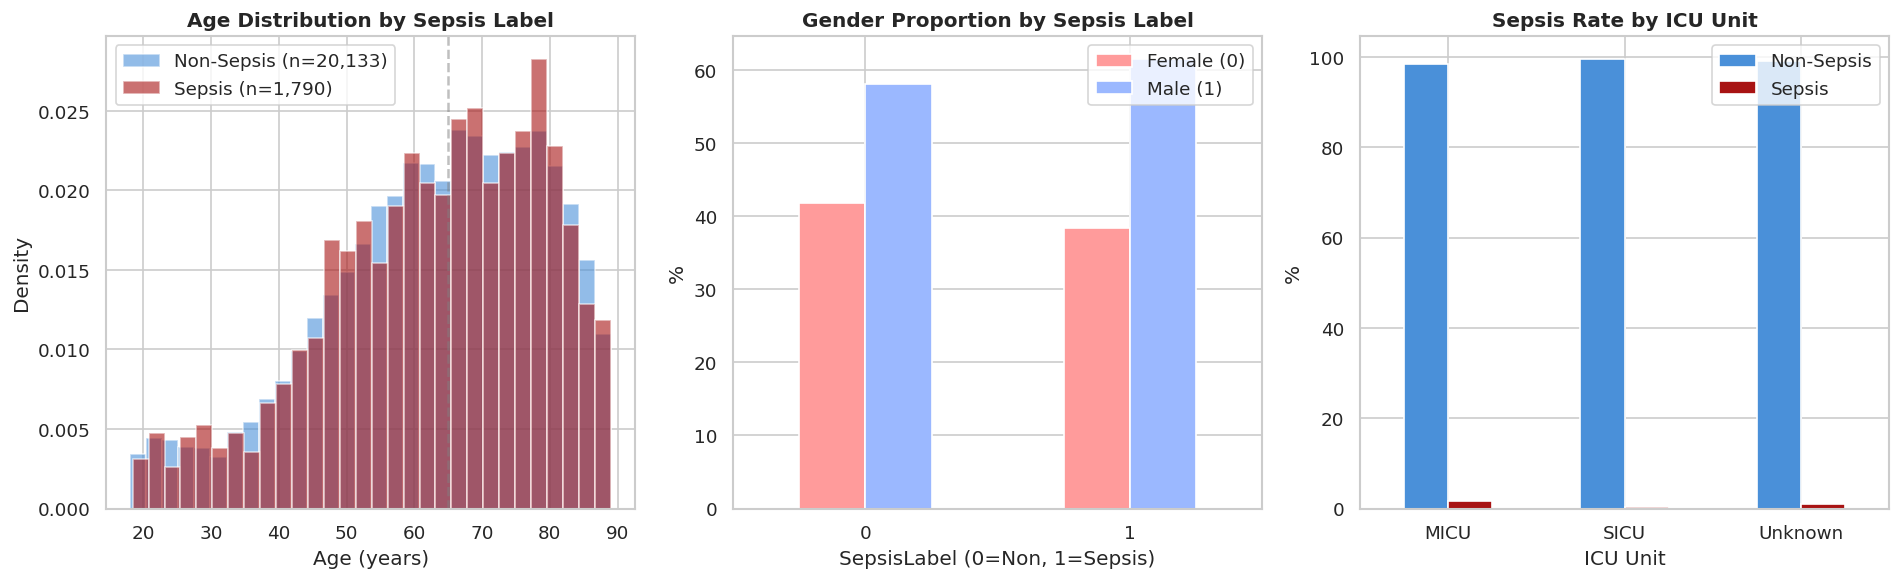


Non-Sepsis Patients:
  Age (median): 65 years
  Male: 58.2%

Sepsis Patients:
  Age (median): 65 years
  Male: 61.0%

 Pasien sepsis cenderung lebih tua, sehingga usia adalah faktor risiko utama sepsis.
 MICU vs SICU mungkin menunjukkan perbedaan case mix dan severity.


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# distribusi umur per kelas
ax = axes[0]
for label, color, name in [(0, COLORS['non_sepsis'], 'Non-Sepsis'), (1, COLORS['sepsis'], 'Sepsis')]:
    age_data = df_raw[df_raw['SepsisLabel'] == label].drop_duplicates('patient_id')['Age'].dropna()
    ax.hist(age_data, bins=30, alpha=0.6, color=color, label=f'{name} (n={len(age_data):,})', density=True)
ax.set_xlabel('Age (years)')
ax.set_ylabel('Density')
ax.set_title('Age Distribution by Sepsis Label', fontweight='bold')
ax.legend()
ax.axvline(65, color='gray', linestyle='--', alpha=0.5, label='Age 65')

# proporsi gender
ax2 = axes[1]
gender_sep = df_raw.drop_duplicates('patient_id').groupby(['SepsisLabel', 'Gender']).size().unstack(fill_value=0)
gender_sep_pct = gender_sep.div(gender_sep.sum(axis=1), axis=0) * 100
gender_sep_pct.plot(kind='bar', ax=ax2, color=['#FF9B9B', '#9BB8FF'], edgecolor='white', rot=0)
ax2.set_title('Gender Proportion by Sepsis Label', fontweight='bold')
ax2.set_xlabel('SepsisLabel (0=Non, 1=Sepsis)')
ax2.set_ylabel('%')
ax2.legend(['Female (0)', 'Male (1)'])

# ICU Unit
ax3 = axes[2]
unit_data = df_raw.drop_duplicates('patient_id').copy()
unit_data['ICU_Unit'] = np.where(
    unit_data['Unit1'] == 1, 'MICU',
    np.where(unit_data['Unit2'] == 1, 'SICU', 'Unknown')
)
unit_sep = unit_data.groupby(['ICU_Unit', 'SepsisLabel']).size().unstack(fill_value=0)
unit_sep_pct = unit_sep.div(unit_sep.sum(axis=1), axis=0) * 100
unit_sep_pct.plot(kind='bar', ax=ax3, color=[COLORS['non_sepsis'], COLORS['sepsis']],
                   edgecolor='white', rot=0)
ax3.set_title('Sepsis Rate by ICU Unit', fontweight='bold')
ax3.set_xlabel('ICU Unit')
ax3.set_ylabel('%')
ax3.legend(['Non-Sepsis', 'Sepsis'])

plt.tight_layout()
plt.savefig('eda_06_demographics.png', dpi=150, bbox_inches='tight')
plt.show()

# Statistik ringkasan
for label in [0, 1]:
    subset = df_raw[df_raw['SepsisLabel'] == label].drop_duplicates('patient_id')
    print(f"\n{'Sepsis' if label else 'Non-Sepsis'} Patients:")
    print(f"  Age (median): {subset['Age'].median():.0f} years")
    print(f"  Male: {(subset['Gender'] == 1).mean()*100:.1f}%")

print('\n Pasien sepsis cenderung lebih tua, sehingga usia adalah faktor risiko utama sepsis.')
print(' MICU vs SICU mungkin menunjukkan perbedaan case mix dan severity.')


## 4.7 — Korelasi Fitur dengan SepsisLabel


=== Top-15 Fitur berkorelasi dengan SepsisLabel ===


,r,pval,significant
ICULOS,0.1503,0.0000,True
Unit1,0.0585,0.0000,True
Unit2,-0.0585,0.0000,True
Bilirubin_direct,0.0563,0.0530,False
Resp,0.0552,0.0000,True
Fibrinogen,0.0545,0.0000,True
TroponinI,-0.0531,0.0993,False
Bilirubin_total,0.0485,0.0000,True
HR,0.0475,0.0000,True
BUN,0.0466,0.0000,True


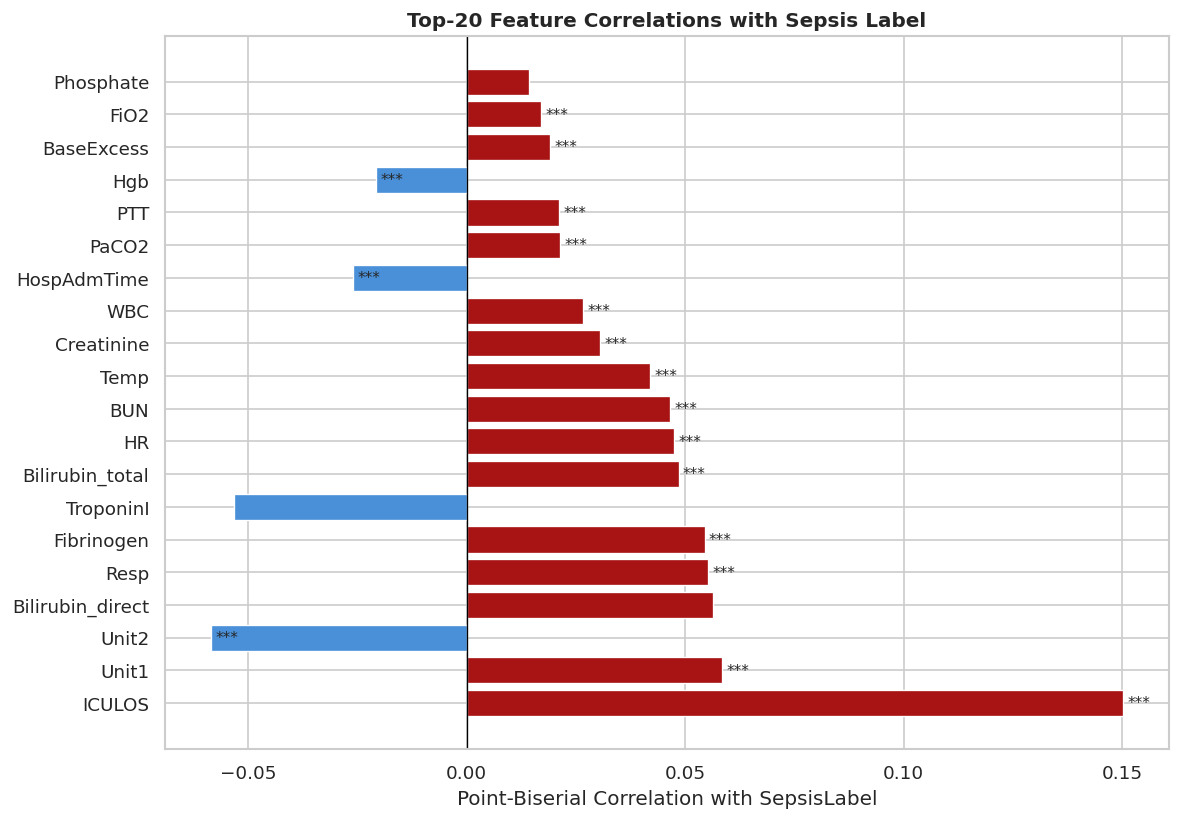

In [14]:
# Point-biserial correlation (ekuivalen Pearson untuk binary target)
numeric_cols = df_raw.select_dtypes(include=np.number).columns.tolist()
numeric_cols = [c for c in numeric_cols if c not in ['SepsisLabel', 'time_step']]

correlations = {}
for col in numeric_cols:
    data_pair = df_raw[[col, 'SepsisLabel']].dropna()
    if len(data_pair) > 100:
        r, pval = stats.pointbiserialr(data_pair[col], data_pair['SepsisLabel'])
        correlations[col] = {'r': r, 'pval': pval}

corr_df = pd.DataFrame(correlations).T
corr_df = corr_df.sort_values('r', key=abs, ascending=False)
corr_df['significant'] = corr_df['pval'] < 0.05

print('=== Top-15 Fitur berkorelasi dengan SepsisLabel ===')
display(corr_df.head(15).round(4))

# Plot
top_n = min(20, len(corr_df))
top_corr = corr_df.head(top_n)

fig, ax = plt.subplots(figsize=(10, 7))
colors_corr = [COLORS['sepsis'] if r > 0 else COLORS['non_sepsis'] for r in top_corr['r']]
bars = ax.barh(top_corr.index, top_corr['r'], color=colors_corr, edgecolor='white', linewidth=0.8)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Point-Biserial Correlation with SepsisLabel')
ax.set_title(f'Top-{top_n} Feature Correlations with Sepsis Label', fontweight='bold')

# Anotasi signifikansi
for bar, (_, row) in zip(bars, top_corr.iterrows()):
    if row['pval'] < 0.001:
        ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
                '***', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('eda_07_correlation.png', dpi=150, bbox_inches='tight')
plt.show()


---
# **5. Data Preprocessing**

Pipeline preprocessing dirancang dengan mempertimbangkan konteks klinis:

| Langkah | Teknik | Alasan Klinis |
|---|---|---|
| **5.1** | Feature Engineering (per-patient aggregation + trend + missing rate) | Data time-series butuh agregasi klinis bermakna |
| **5.2** | Median Imputation | Lebih robust terhadap outlier medis |
| **5.3** | Zero-Variance Removal | Fitur konstan tidak informatif |
| **5.4** | SMOTE | Handle class imbalance |
| **5.5** | StandardScaler | Normalisasi untuk model berbasis jarak/gradien |


## 5.1 — Feature Engineering

Kita mengubah time-series per pasien menjadi satu baris per pasien dengan fitur-fitur:
- **Statistik agregasi**: mean, std, min, max, last dari setiap kolom numerik
- **Trend slope**: kemiringan regresi linear untuk vital signs (apakah memburuk?)
- **Missing rate**: proporsi nilai kosong per fitur per pasien (informasi klinis!)
- **SOFA score proxy**: estimasi severity organ dysfunction


In [15]:
# Kolom fitur numerik (diluar ID dan label)
FEATURE_COLS = [c for c in df_raw.columns 
                if c not in ['patient_id', 'time_step', 'SepsisLabel']
                and df_raw[c].dtype in [np.float64, np.int64, float, int]]

TREND_COLS = ['HR', 'O2Sat', 'Temp', 'SBP', 'MAP', 'Resp']


def compute_trend_slope(series):
    """Hitung kemiringan regresi linear dari series (waktu ke nilai)."""
    valid = series.dropna()
    if len(valid) < 3:
        return np.nan
    x = np.arange(len(valid))
    slope, *_ = linregress(x, valid.values)
    return slope


def engineer_patient_features(patient_df):
    feats = {}
    
    # 1. Statistik Agregasi
    for col in FEATURE_COLS:
        if col not in patient_df.columns:
            continue
        s = patient_df[col]
        feats[f'{col}_mean']  = s.mean()
        feats[f'{col}_std']   = s.std()
        feats[f'{col}_min']   = s.min()
        feats[f'{col}_max']   = s.max()
        feats[f'{col}_last']  = s.dropna().iloc[-1] if s.dropna().shape[0] > 0 else np.nan
        
        #2. Missing Rate (sebagai fitur klinis)
        feats[f'{col}_missing_rate'] = s.isnull().mean()
    
    #3. Trend Slope (vital signs)
    for col in TREND_COLS:
        if col in patient_df.columns:
            feats[f'{col}_trend'] = compute_trend_slope(patient_df[col])
    
    # 4. SOFA Score Proxy 
    # Respiratory: PaO2/FiO2 proxy → menggunakan O2Sat/FiO2
    sofa_resp = 0
    if 'O2Sat' in patient_df.columns and 'FiO2' in patient_df.columns:
        o2sat_mean = patient_df['O2Sat'].mean()
        fio2_mean  = patient_df['FiO2'].replace(0, np.nan).mean()
        if not pd.isna(o2sat_mean) and not pd.isna(fio2_mean) and fio2_mean > 0:
            pf_ratio = (o2sat_mean / 100 * 100) / fio2_mean  # simplified
            sofa_resp = 0 if pf_ratio > 400 else 1 if pf_ratio > 300 else 2 if pf_ratio > 200 else 3
    
    # Renal: Creatinine
    sofa_renal = 0
    if 'Creatinine' in patient_df.columns:
        cr = patient_df['Creatinine'].mean()
        if not pd.isna(cr):
            sofa_renal = 0 if cr < 1.2 else 1 if cr < 2.0 else 2 if cr < 3.5 else 3
    
    # Hepatic: Bilirubin
    sofa_liver = 0
    if 'Bilirubin_total' in patient_df.columns:
        bil = patient_df['Bilirubin_total'].mean()
        if not pd.isna(bil):
            sofa_liver = 0 if bil < 1.2 else 1 if bil < 2.0 else 2 if bil < 6.0 else 3
    
    # Coagulation: Platelets
    sofa_coag = 0
    if 'Platelets' in patient_df.columns:
        plt_val = patient_df['Platelets'].mean()
        if not pd.isna(plt_val):
            sofa_coag = 0 if plt_val > 150 else 1 if plt_val > 100 else 2 if plt_val > 50 else 3
    
    feats['sofa_proxy'] = sofa_resp + sofa_renal + sofa_liver + sofa_coag
    
    #5. Target: apakah pasien pernah sepsis? 
    feats['SepsisLabel'] = int(patient_df['SepsisLabel'].max())
    
    return feats




In [16]:
try:
    from tqdm.auto import tqdm
    HAS_TQDM = True
except ImportError:
    HAS_TQDM = False

patient_groups = df_raw.groupby('patient_id')
all_patient_feats = []

iterator = tqdm(patient_groups, desc='Feature Engineering') if HAS_TQDM else patient_groups

for pid, group in iterator:
    feat_dict = engineer_patient_features(group)
    feat_dict['patient_id'] = pid
    all_patient_feats.append(feat_dict)

df_features = pd.DataFrame(all_patient_feats)
df_features = df_features.set_index('patient_id')

print(f'\n Gokill done bang')
print(f'Shape: {df_features.shape}')
print(f'Fitur baru: {df_features.shape[1] - 1} (diluar label)')
print(f'Contoh fitur: {list(df_features.columns[:10])}')
display(df_features.head(3))


Feature Engineering:   0%|          | 0/20336 [00:00<?, ?it/s]


 Gokill done bang
Shape: (20336, 248)
Fitur baru: 247 (diluar label)
Contoh fitur: ['HR_mean', 'HR_std', 'HR_min', 'HR_max', 'HR_last', 'HR_missing_rate', 'O2Sat_mean', 'O2Sat_std', 'O2Sat_min', 'O2Sat_max']


,HR_mean,HR_std,HR_min,HR_max,HR_last,HR_missing_rate,O2Sat_mean,O2Sat_std,O2Sat_min,O2Sat_max,...,ICULOS_last,ICULOS_missing_rate,HR_trend,O2Sat_trend,Temp_trend,SBP_trend,MAP_trend,Resp_trend,sofa_proxy,SepsisLabel
patient_id,,,,,,,,,,,,,,,,,,,,,
p000001,101.571429,9.594378,76.0,117.0,84.0,0.092593,91.477273,3.460667,85.0,100.0,...,54,0.0,-0.227041,0.001057,0.017091,-0.370878,-0.449148,-0.075246,1,0
p000002,60.954545,8.144395,54.0,94.0,55.0,0.043478,97.000000,2.138090,94.0,100.0,...,23,0.0,-0.442123,-0.196499,-0.066000,0.653571,-1.086674,-0.342982,2,0
p000003,79.611111,6.714036,68.0,93.0,78.0,0.062500,95.431818,1.655122,91.0,99.0,...,48,0.0,-0.318775,-0.006836,-0.056015,0.212648,0.359352,-0.047760,3,0


## 5.2 — Pemisahan Fitur dan Target + Train/Test Split


In [17]:
# Pisah X dan y
y = df_features['SepsisLabel'].values
X = df_features.drop(columns=['SepsisLabel'])

print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')
print(f'Sepsis rate: {y.mean()*100:.1f}%')

# Train/Test Split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'\nTrain: {X_train.shape}, Test: {X_test.shape}')
print(f'Train sepsis rate: {y_train.mean()*100:.1f}%')
print(f'Test  sepsis rate: {y_test.mean()*100:.1f}%')


X shape: (20336, 247)
y shape: (20336,)
Sepsis rate: 8.8%

Train: (16268, 247), Test: (4068, 247)
Train sepsis rate: 8.8%
Test  sepsis rate: 8.8%


## 5.3 — Median Imputation

> **Alasan:** Median lebih robust terhadap distribusi skewed yang umum pada data medis (dibandingkan mean). Imputation dilakukan hanya dari data train untuk menghindari data leakage.


In [18]:
# Before imputation, drop any feature that is completely missing in the training set.
all_nan_cols = X_train.columns[X_train.isna().all()].tolist()
if all_nan_cols:
    print(f"dropping {len(all_nan_cols)} columns with all NaN in train: {all_nan_cols}")
    X_train = X_train.drop(columns=all_nan_cols)
    X_test  = X_test.drop(columns=all_nan_cols)

# compute medians from training set only (avoid leakage)
median_vals = X_train.median()

X_train_imp = X_train.fillna(median_vals)
X_test_imp  = X_test.fillna(median_vals)

print(f"Imputation done using pandas median, shapes: {X_train_imp.shape}, {X_test_imp.shape}")

# Verifikasi
remaining_nan_train = X_train_imp.isnull().sum().sum()
remaining_nan_test  = X_test_imp.isnull().sum().sum()
print(f'gokss done hehe')
print(f'missing setelah imputasi Train: {remaining_nan_train}, Test: {remaining_nan_test}')

dropping 5 columns with all NaN in train: ['EtCO2_mean', 'EtCO2_std', 'EtCO2_min', 'EtCO2_max', 'EtCO2_last']
Imputation done using pandas median, shapes: (16268, 242), (4068, 242)
gokss done hehe
missing setelah imputasi Train: 0, Test: 0


## 5.4 Hapus Fitur Zero-Variance


In [19]:
selector = VarianceThreshold(threshold=0.0)
selector.fit(X_train_imp)

kept_cols = X_train_imp.columns[selector.get_support()].tolist()
removed_cols = [c for c in X_train_imp.columns if c not in kept_cols]

X_train_var = X_train_imp[kept_cols]
X_test_var  = X_test_imp[kept_cols]

print(f'donee:')
print(f'Fitur dihapus : {len(removed_cols)} → {removed_cols}')
print(f'Fitur tersisa : {len(kept_cols)}')


donee:
Fitur dihapus : 8 → ['EtCO2_missing_rate', 'Age_missing_rate', 'Gender_std', 'Gender_missing_rate', 'Unit1_std', 'Unit2_std', 'HospAdmTime_missing_rate', 'ICULOS_missing_rate']
Fitur tersisa : 234


## 5.5 SMOTE (Oversampling Kelas Minoritas)

> **Catatan:** SMOTE hanya diterapkan pada data **TRAIN** — tidak pada test set. Ini penting untuk evaluasi yang realistik.


Distribusi sebelum SMOTE: {np.int64(0): np.int64(14836), np.int64(1): np.int64(1432)}
Distribusi setelah SMOTE : {np.int64(0): np.int64(14836), np.int64(1): np.int64(14836)}
Shape setelah SMOTE      : (29672, 234)


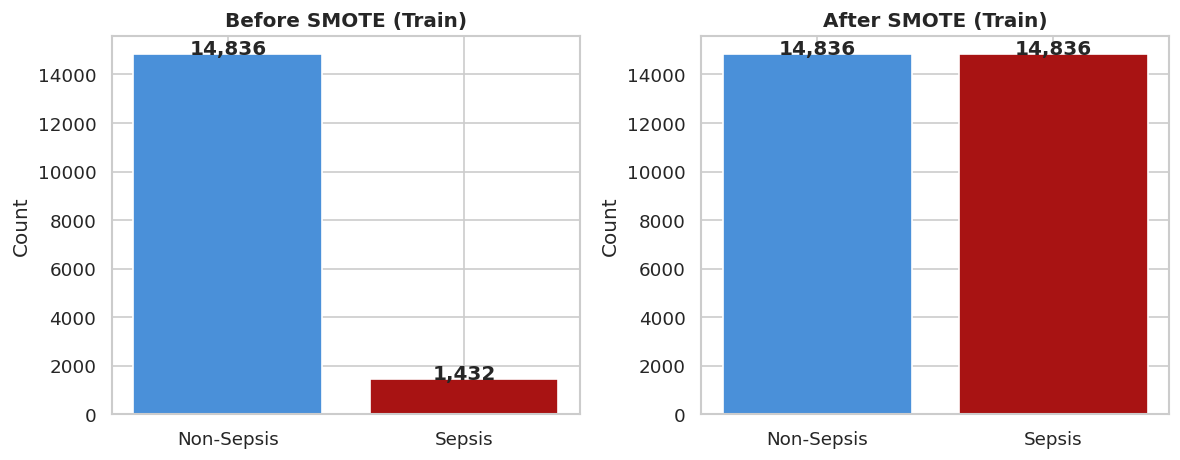

In [20]:
print(f'Distribusi sebelum SMOTE: {dict(zip(*np.unique(y_train, return_counts=True)))}')

smote = SMOTE(random_state=42, k_neighbors=5)
X_train_sm, y_train_sm = smote.fit_resample(X_train_var, y_train)

print(f'Distribusi setelah SMOTE : {dict(zip(*np.unique(y_train_sm, return_counts=True)))}')
print(f'Shape setelah SMOTE      : {X_train_sm.shape}')

# Visualisasi before/after
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, y_data, title in zip(
    axes,
    [y_train, y_train_sm],
    ['Before SMOTE (Train)', 'After SMOTE (Train)']
):
    unique, counts = np.unique(y_data, return_counts=True)
    bars = ax.bar(['Non-Sepsis', 'Sepsis'], counts,
                  color=[COLORS['non_sepsis'], COLORS['sepsis']], edgecolor='white')
    for bar, cnt in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                f'{cnt:,}', ha='center', fontweight='bold')
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Count')

plt.tight_layout()
plt.savefig('preprocessing_smote.png', dpi=150, bbox_inches='tight')
plt.show()


## 5.6 StandardScaler


In [21]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_sm)
X_test_scaled  = scaler.transform(X_test_var)

X_train_final = pd.DataFrame(X_train_scaled, columns=kept_cols)
X_test_final  = pd.DataFrame(X_test_scaled,  columns=kept_cols)

print(f'done.')
print(f'Train mean (sample): {X_train_final.iloc[:, :3].mean().round(4).to_dict()}')
print(f'Train std  (sample): {X_train_final.iloc[:, :3].std().round(4).to_dict()}')


done.
Train mean (sample): {'HR_mean': 0.0, 'HR_std': -0.0, 'HR_min': 0.0}
Train std  (sample): {'HR_mean': 1.0, 'HR_std': 1.0, 'HR_min': 1.0}


## 5.7 Simpan Dataset Preprocessing


In [23]:
import os
os.makedirs('sepsis_preprocessing', exist_ok=True)

# Simpan train & test
df_train_out = X_train_final.copy()
df_train_out['SepsisLabel'] = y_train_sm
df_train_out.to_csv('sepsis_preprocessing/train_preprocessed.csv', index=False)

df_test_out = X_test_final.copy()
df_test_out['SepsisLabel'] = y_test
df_test_out.to_csv('sepsis_preprocessing/test_preprocessed.csv', index=False)

# Simpan metadata preprocessing
metadata = {
    'n_features'         : len(kept_cols),
    'feature_names'      : kept_cols,
    'imputer_strategy'   : 'median',
    'smote_applied'      : True,
    'scaler'             : 'StandardScaler',
    'train_shape'        : list(X_train_final.shape),
    'test_shape'         : list(X_test_final.shape),
    'train_sepsis_rate'  : float(y_train_sm.mean()),
    'test_sepsis_rate'   : float(y_test.mean()),
    'removed_zero_var'   : removed_cols,
}
with open('sepsis_preprocessing/preprocessing_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print('Dataset berhasil disimpan ke folder sepsis_preprocessing/')
print(f'Train: sepsis_preprocessing/train_preprocessed.csv → {X_train_final.shape}')
print(f'Test : sepsis_preprocessing/test_preprocessed.csv  → {X_test_final.shape}')
print(f'Meta : sepsis_preprocessing/preprocessing_metadata.json')

# Ringkasan akhir
print('RINGKASAN PIPELINE PREPROCESSING')
print(f'Raw data         : {df_raw.shape[0]:,} rows × {df_raw.shape[1]} cols')
print(f'Setelah FE       : {df_features.shape[0]:,} patients × {df_features.shape[1]-1} features')
print(f'Setelah imputation + var: {X_train_var.shape[1]} features')
print(f'Setelah SMOTE    : {X_train_sm.shape[0]:,} samples (train)')
print(f'Final train      : {X_train_final.shape}')
print(f'Final test       : {X_test_final.shape}')


Dataset berhasil disimpan ke folder sepsis_preprocessing/
Train: sepsis_preprocessing/train_preprocessed.csv → (29672, 234)
Test : sepsis_preprocessing/test_preprocessed.csv  → (4068, 234)
Meta : sepsis_preprocessing/preprocessing_metadata.json
RINGKASAN PIPELINE PREPROCESSING
Raw data         : 790,215 rows × 43 cols
Setelah FE       : 20,336 patients × 247 features
Setelah imputation + var: 234 features
Setelah SMOTE    : 29,672 samples (train)
Final train      : (29672, 234)
Final test       : (4068, 234)
